**IMPORTS**

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import kagglehub
import random


# Setting a seed to get the same accuracy results every time
seed_value = 33

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [3]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


**LOADING DATA**

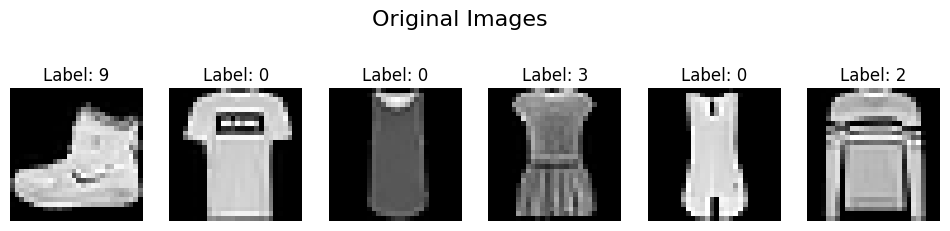

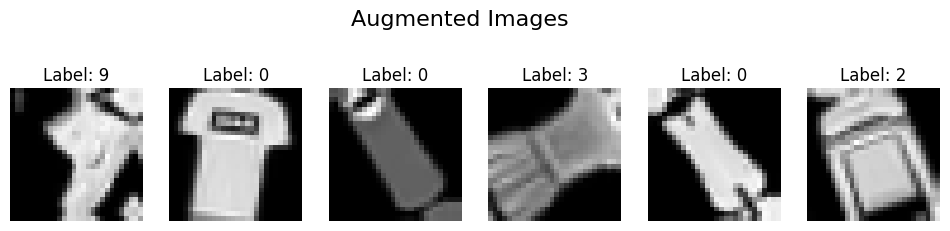

In [4]:
DATA_PATH = path

# Step 1: Load the Fashion MNIST Dataset from local
def load_fashion_mnist_data(path, kind='train'):
    """Load Fashion MNIST data from idx3-ubyte files."""
    if kind == 'train':
        labels_filename = 'train-labels-idx1-ubyte'
        images_filename = 'train-images-idx3-ubyte'
    else:
        labels_filename = 't10k-labels-idx1-ubyte'
        images_filename = 't10k-images-idx3-ubyte'

    labels_path = os.path.join(path, labels_filename)
    images_path = os.path.join(path, images_filename)

    with open(labels_path, 'rb') as lbpath:
        lbpath.seek(8)
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        imgpath.seek(16)
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 28, 28)

    return images, labels
try:
    # Load training data
    train_images, train_labels = load_fashion_mnist_data(DATA_PATH, kind='train')
    # Load test data
    test_images, test_labels = load_fashion_mnist_data(DATA_PATH, kind='t10k')
except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print(f"Please make sure the data files are located in the '{DATA_PATH}' directory.")
    exit()

# Define class names for the labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Step 2: Adding some data augmentation to increase the training dataset
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=seed_value),
    tf.keras.layers.RandomRotation(0.2, seed=seed_value),
    tf.keras.layers.RandomZoom(0.2, seed=seed_value)
])

# Step 3: Preprocess the Data, normilize pixel data from 0~255 to 0~1.0
train_images = train_images / 255.0
test_images = test_images / 255.0

augmented_images = augmenter(train_images[..., None])  #  Keras data augmentation expects a channel dimension (1 because it's grayscale)
augmented_images = tf.squeeze(augmented_images).numpy()  # remove channel dimension


# Concatenate with original data
train_images_expanded = np.concatenate([train_images, augmented_images], axis=0)
train_labels_expanded = np.concatenate([train_labels, train_labels], axis=0)

def show_samples(images, labels, title, num=6):
    plt.figure(figsize=(12, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(num):
        plt.subplot(1, num, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.show()

# Original images
show_samples(train_images, train_labels, "Original Images")

# Augmented images
show_samples(augmented_images, train_labels, "Augmented Images")




# 新段落

**MODEL**

In [5]:
# Step 4: Build the Neural Network Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(124, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display a summary of the model's architecture
print("Model Summary:")
model.summary()

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,078 (914.37 KB)

 Trainable params: 234,078 (914.37 KB)

 Non-trainable params: 0 (0.00 B)

**TRAINING**

In [6]:
# Step 6: Train the Model
print("\nStarting model training...")
history = model.fit(train_images_expanded, train_labels_expanded, epochs=15, validation_split=0.1)
print("Model training finished.")



Starting model training...
Epoch 1/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7241 - loss: 0.7703 - val_accuracy: 0.7623 - val_loss: 0.6473
Epoch 2/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8214 - loss: 0.4825 - val_accuracy: 0.7868 - val_loss: 0.5796
Epoch 3/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8412 - loss: 0.4272 - val_accuracy: 0.7937 - val_loss: 0.5557
Epoch 4/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8534 - loss: 0.3914 - val_accuracy: 0.8003 - val_loss: 0.5417
Epoch 5/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8627 - loss: 0.3660 - val_accuracy: 0.8073 - val_loss: 0.5304
Epoch 6/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8702 - loss: 0.3467 - val_accuracy: 0.8087 - val_loss: 0.5213
Epoch 7/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8770 - loss: 0.3283 - val_accuracy: 0.8089 - val_loss: 0.5296
Epoch 8/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - a

**PLOTTING HELPER FUNCS**

In [7]:
# Helper functions to visualize the predictions
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

**TESTING**


Evaluating model on test data...
313/313 - 2s - 7ms/step - accuracy: 0.8745 - loss: 0.4189

Test accuracy: 0.8745
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Visualizing a prediction...


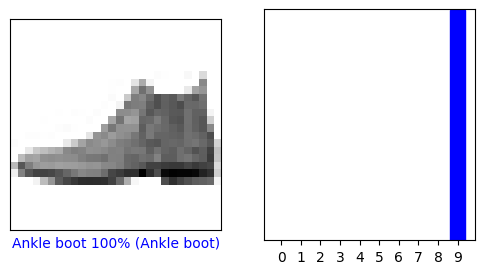


Plotting training history...


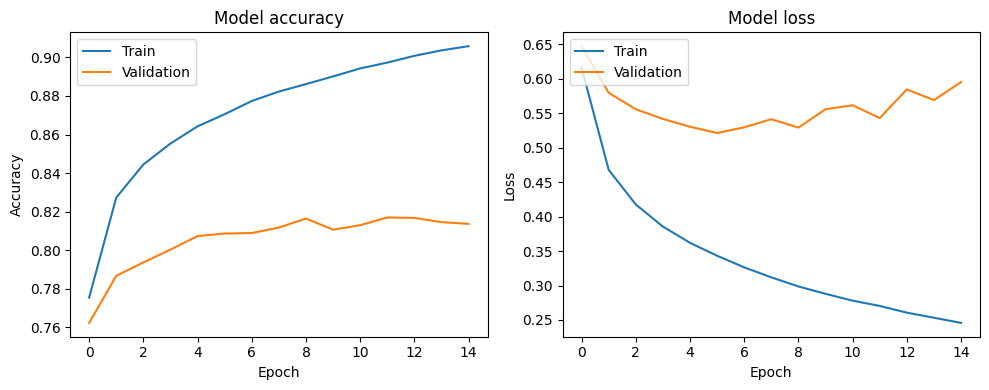

In [8]:
# Step 7: Evaluate the Model's Accuracy
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

# Step 8: Make Predictions
predictions = model.predict(test_images)


# Let's visualize the prediction for the first image
print("\nVisualizing a prediction...")
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

# Plot training & validation accuracy values
print("\nPlotting training history...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

Additional Test

1. Define Image Loading and Preprocessing Function

This function handles opening the image, converting it to grayscale, resizing it to $28 \times 28$ pixels, and finally normalizing the pixel values to the range $[0, 1]$ for model input.

In [19]:
from PIL import Image
!git clone https://github.com/kkbin505/MEng_classify_fashion_MNIST.git
# --- Configuration ---
IMAGE_PATH = 'MEng_classify_fashion_MNIST/img/test_tshirt.jpg'
TARGET_SIZE = 28
OUTPUT_SHAPE = (1, TARGET_SIZE, TARGET_SIZE, 1)

# Fashion MNIST labels
K_CATEGORY_LABELS = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 1. Load the saved model
# model = tf.keras.models.load_model("fashion_mnist_model.keras")
def load_image(image_path):
    """Load, convert to grayscale, resize, and normalize the image."""
    try:
        # 1. Open the image and convert to grayscale ('L')
        img = Image.open(image_path).convert('L')
    except FileNotFoundError:
        print(f"❌ Error: File not found at {image_path}")
        return None, None

    # 2. Resize the image to 28x28
    img = img.resize((28, 28))

    # 3. Convert to numpy array and normalize to [0, 1]
    # img_visual is kept 0-255 for display purposes
    img_visual = np.array(img, dtype=np.uint8)
    # img_array is normalized to 0.0-1.0 for model input
    img_array = np.array(img, dtype=np.float32) / 255.0



    # 4. Add batch dimension: (1, 28, 28)
    img_array = img_array.reshape(1, 28, 28)

    return img_array , img_visual

# Load and preprocess the image
new_image, img_visual = load_image(IMAGE_PATH)

if new_image is not None:
    print(f"Original Image Path: {IMAGE_PATH}")
    print(f"Model Input Array Shape: {new_image.shape}")


fatal: destination path 'MEng_classify_fashion_MNIST' already exists and is not an empty directory.
Original Image Path: MEng_classify_fashion_MNIST/img/test_tshirt.jpg
Model Input Array Shape: (1, 28, 28)


2. Image Visualization and Saving

Explanation: Use matplotlib to display the $28 \times 28$ preprocessed image directly in the Notebook for visual inspection. The processed array and image are also saved to disk.

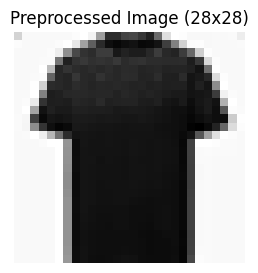


✅ Saved NumPy array to: MEng_classify_fashion_MNIST/preprocessed_input.npy
✅ Saved visualization image to: MEng_classify_fashion_MNIST/img/preprocessed_28x28.jpg


In [22]:
if new_image is not None:

    # --- A. Display the preprocessed image (0-255) in the Notebook ---
    plt.figure(figsize=(3, 3))
    # Inverse color
    img_visual = 255 -img_visual
    plt.imshow(img_visual, cmap='gray')
    plt.title(f"Preprocessed Image ({img_visual.shape[0]}x{img_visual.shape[1]})")
    plt.axis('off')
    plt.show()


    # --- B. Save NumPy array (Optional) ---
    np_save_path = 'MEng_classify_fashion_MNIST/preprocessed_input.npy'
    np.save(np_save_path, new_image)
    print(f"\n✅ Saved NumPy array to: {np_save_path}")

    # --- C. Save JPG image (Optional) ---
    img_to_save = Image.fromarray(img_visual)
    jpg_save_path = 'MEng_classify_fashion_MNIST/img/preprocessed_28x28.jpg'

    # Ensure grayscale mode ('L') for saving
    if img_to_save.mode != 'L':
         img_to_save = img_to_save.convert('L')

    img_to_save.save(jpg_save_path)
    print(f"✅ Saved visualization image to: {jpg_save_path}")

3. Prediction



In [24]:
if new_image is not None:

    # --- Critical Preprocessing Step: Color Inversion (To match Fashion MNIST training data) ---
    # Fashion MNIST data is typically dark background (0) and light foreground (1).
    # If your input image is light background, you need to invert the colors (1.0 - array).
    new_image_processed = 1.0 - new_image

    # Make prediction
    # Check if the model requires a channel dimension (e.g., (1, 28, 28, 1))
    if model.input_shape[-1] == 1 and new_image_processed.ndim == 3:
        # Add the channel dimension
        new_image_processed = new_image_processed[..., np.newaxis]

    # Perform prediction
    prediction = model.predict(new_image_processed, verbose=0)

    # Get the predicted class index and confidence
    predicted_class = np.argmax(prediction[0])
    confidence = 100 * np.max(prediction[0])


    # --- Print Results ---
    print("--- Prediction Result ---")
    print(f"**Predicted Class**: {K_CATEGORY_LABELS[predicted_class]}")
    print(f"**Confidence**: {confidence:.2f}%")
    print("\n--- Full Probability Distribution ---")

    # Display the full probability distribution using a table
    results = []
    for i, label in enumerate(K_CATEGORY_LABELS):
        results.append((label, f"{prediction[0][i]*100:.2f}%"))

    print(f"| Category | Probability |")
    print(f"| :--- | ---: |")
    for label, prob in results:
        print(f"| {label} | {prob} |")

--- Prediction Result ---
**Predicted Class**: T-shirt/top
**Confidence**: 96.95%

--- Full Probability Distribution ---
| Category | Probability |
| :--- | ---: |
| T-shirt/top | 96.95% |
| Trouser | 0.00% |
| Pullover | 0.00% |
| Dress | 0.00% |
| Coat | 0.00% |
| Sandal | 0.00% |
| Shirt | 3.05% |
| Sneaker | 0.00% |
| Bag | 0.00% |
| Ankle boot | 0.00% |
